In [1]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import InMemoryVectorStore
from langchain_ollama import OllamaEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_ollama import ChatOllama
DEBUG_MODE = False

# --- Create an index of documents ---
urls=[
    "https://blog.langchain.dev/top-5-langgraph-agents-in-production-2024/",
    "https://blog.langchain.dev/langchain-state-of-ai-2024/",
    "https://blog.langchain.dev/introducing-ambient-agents/"
]
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

if DEBUG_MODE:  # switch to True for debugging
    doc = docs[0][0]
    text = doc.page_content
    clean = "\n".join(line for line in text.splitlines() if line.strip())

    print(doc.metadata)
    print(f"Total length: {len(clean)}")
    print(clean[:1000])

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=250, chunk_overlap=0)
doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorDB
vectorstore = InMemoryVectorStore.from_documents(documents= doc_splits, embedding=OllamaEmbeddings(model="mxbai-embed-large"))
retriever = vectorstore.as_retriever()

# Retrieve the relevant documents
results = retriever.invoke("what are 2 LangGraph agents used in production in 2024?")
print("Results: \n", results)

/home/paminidigehsara/Desktop/LangChain/.langchain_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


Results: 
 [Document(id='fcd718e0-dfb7-425b-813f-cc45a6b7bb5b', metadata={'source': 'https://blog.langchain.dev/top-5-langgraph-agents-in-production-2024/', 'title': 'Top 5 LangGraph Agents in Production 2024', 'description': 'Discover how Replit, LinkedIn, Uber, Elastic & AppFolio built production-ready AI agents with LangGraph in 2024. Real case studies and lessons learned.', 'language': 'en'}, page_content='2024 was the year that agents started to work in production. Not the wide-ranging, fully autonomous agents that people imagined with AutoGPT. But more vertical, narrowly scoped, highly controllable agents with custom cognitive architectures. It\'s still not easy to build these agents - but it\'s entirely possible.We launched LangGraph in early 2024 as a new take on an agentic framework. Incorporating lessons learned from LangChain, we made LangGraph very low level, controllable agentic framework. No hidden prompts, no obfuscated "cognitive architecture". Soon after it\'s launch, 

In [15]:
### Retrieval Grader

from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_ollama import ChatOllama

# Data model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""
    binary_score: str = Field(description="Documents are relevant to the question, 'yes' or 'no'")

# LLM with function call
llm_model = ChatOllama(model="llama3.1:latest", temperature=0)
structured_llm_grader = llm_model.with_structured_output(GradeDocuments)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question.
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant.
    Give a binary score 'yes' or 'no' to indicate wether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages([("system", system),
                                                 ("human", "Retrieved document: \n\n {document} \n\n User question: {question}")])

retrieval_grader = grade_prompt | structured_llm_grader
question = "agent memory"
docs = retriever.invoke(question)
doc_txt = docs[0].page_content # as an example
retrieval_grader.invoke({"question": question, "document": doc_txt})

GradeDocuments(binary_score='no')

In [8]:
doc_txt

'2024 was the year that agents started to work in production. Not the wide-ranging, fully autonomous agents that people imagined with AutoGPT. But more vertical, narrowly scoped, highly controllable agents with custom cognitive architectures. It\'s still not easy to build these agents - but it\'s entirely possible.We launched LangGraph in early 2024 as a new take on an agentic framework. Incorporating lessons learned from LangChain, we made LangGraph very low level, controllable agentic framework. No hidden prompts, no obfuscated "cognitive architecture". Soon after it\'s launch, we saw LangGraph become the go-to default framework for agents.As the year closes, we wanted to highlight some of our favorite stories of companies building agents with LangGraph. As mentioned before, it\'s still hard to build agents, but these companies have figured out how. They\'ve shared their lessons learned in various forms - blogs, case studies, talks, fireside chats. We hope that by amplifying their st

In [9]:
doc_splits

[Document(metadata={'source': 'https://blog.langchain.dev/top-5-langgraph-agents-in-production-2024/', 'title': 'Top 5 LangGraph Agents in Production 2024', 'description': 'Discover how Replit, LinkedIn, Uber, Elastic & AppFolio built production-ready AI agents with LangGraph in 2024. Real case studies and lessons learned.', 'language': 'en'}, page_content='Top 5 LangGraph Agents in Production 2024\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nProducts\n\nLangSmith Platform\n\nObservabilitySee exactly what your agents are doingEvaluationScore and improve agent performanceDeploymentShip and scale agents in productionFleetAgents for the whole companyOpen Source FrameworksdeepagentsBuild long-running agents for complex taskslangchainQuick start agents with any model providerlanggraphBuild reliable agents with low-level controlLearn\n\nResourcesBlogCustomer StoriesGuidesMax AgencyHow-ToLangChain AcademyYouTubeDocumentationCommunityLangSmith for 

# P:222 Full repo and graph
https://github.com/langchain-ai/learning-langchain/blob/master/ch10/py/search_graph.py

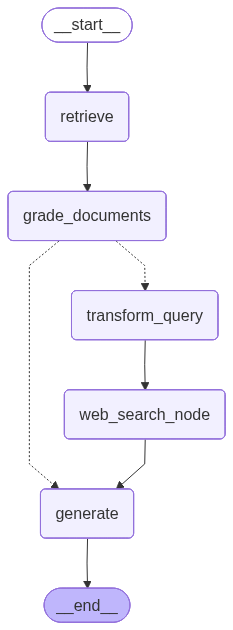

In [17]:
from typing import List, TypedDict

from langchain import hub
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_ollama import ChatOllama
from langgraph.graph import END, START, StateGraph
from langchain_core.prompts import ChatPromptTemplate


# prompt
prompt = ChatPromptTemplate.from_template(
    """You are an assistant for question-answering tasks.
Use the following retrieved context to answer the question.
If you don't know the answer, just say you don't know.
Use three sentences maximum and keep the answer concise.

Question: {question}

Context: {context}

Answer:
"""
)

# llm
llm = ChatOllama(model="llama3.1:latest", temperature=0)

rag_chain = prompt | llm | StrOutputParser()

# rewrite prompt
system = """You are a question re-writer that converts an input question to a better version optimized for web search.
Look at the input and reason about the underlying semantic intent."""
re_write_prompt = ChatPromptTemplate.from_messages([
    ("system", system),
    ("human", "Here is the initial question:\n\n{question}\n\nFormulate an improved question.")
])

question_rewriter = re_write_prompt | llm | StrOutputParser()

web_search_tool = DuckDuckGoSearchResults(output_format="list")

class GraphState(TypedDict):
    question: str
    generation: str
    web_search: str
    documents: List[Document]

def retrieve(state: GraphState):
    question = state["question"]
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

def generate(state: GraphState):
    question = state["question"]
    documents = state["documents"]
    context = "\n\n".join(doc.page_content for doc in documents)
    generation = rag_chain.invoke({"context": context, "question": question})
    return {"documents": documents, "question": question, "generation": generation}

def grade_documents(state: GraphState):
    question = state["question"]
    documents = state["documents"]

    filtered_docs = []
    web_search = "No"

    for d in documents:
        score = retrieval_grader.invoke({
            "question": question,
            "document": d.page_content
        })
        if score.binary_score == "yes":
            filtered_docs.append(d)
        else:
            web_search = "Yes"

    return {"documents": filtered_docs, "question": question, "web_search": web_search}

def transform_query(state: GraphState):
    question = state["question"]
    documents = state["documents"]
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}

def web_search(state: GraphState):
    question = state["question"]
    documents = state["documents"]

    results = web_search_tool.invoke(question)
    web_results_text = "\n".join(
        f"{item.get('title', '')}\n{item.get('snippet', '')}"
        for item in results
    )
    documents.append(Document(page_content=web_results_text))

    return {"documents": documents, "question": question}

def decide_to_generate(state: GraphState):
    if state["web_search"] == "Yes":
        return "transform_query"
    return "generate"

workflow = StateGraph(GraphState)
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("transform_query", transform_query)
workflow.add_node("web_search_node", web_search)

workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

app = workflow.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

## Upload test dataset to langsmith
upload to an exsiting dataset with ID

In [ ]:
# from dotenv import load_dotenv
# from langsmith import Client

# load_dotenv()

# client = Client()

# DATASET_ID = "8fc3bc76-9b19-48fe-b2d3-012f1bb80f2b"

# examples = [
#     {
#         "question": "Which companies are highlighted as top LangGraph agent adopters in 2024?",
#         "answer": "The top adopters include Uber (code migration tools), AppFolio (property management copilot), LinkedIn (SQL Bot), Elastic (AI assistant), and Replit (multi-agent development platform)."
#     },
#     {
#         "question": "How did AppFolio's AI copilot impact property managers?",
#         "answer": "AppFolio's Realm-X AI copilot saved property managers over 10 hours per week by automating queries, bulk actions, and scheduling."
#     },
#     {
#         "question": "What infrastructure trends dominated LLM usage in 2024?",
#         "answer": "OpenAI remained the top LLM provider (6x more usage than Ollama), while open-source models via Ollama and Groq surged. Chroma and FAISS led vector stores, with MongoDB and Elastic gaining traction."
#     },
#     {
#         "question": "How did LangGraph improve agent workflows compared to 2023?",
#         "answer": "LangGraph usage grew to 43% of LangSmith organizations, with 21.9% of traces involving tool calls (up from 0.5% in 2023), enabling complex multi-step tasks like database writes."
#     },
#     {
#         "question": "What distinguishes Replit's LangGraph implementation?",
#         "answer": "Replit's agent emphasizes human-in-the-loop validation and a multi-agent architecture for code generation, combining autonomy with controlled outputs."
#     }
# ]

# formatted_examples = [
#     {
#         "inputs": {"question": ex["question"]},
#         "outputs": {"answer": ex["answer"]},
#         "metadata": {"source": "langchain blogs"}
#     }
#     for ex in examples
# ]

# dataset = client.read_dataset(dataset_id=DATASET_ID)

# client.create_examples(
#     dataset_id=dataset.id,
#     examples=formatted_examples
# )

# print(f"Added {len(formatted_examples)} examples to dataset: {dataset.id}")
# print(dataset.url)

Added 5 examples to dataset: 8fc3bc76-9b19-48fe-b2d3-012f1bb80f2b
https://smith.langchain.com/o/6d4bdaec-72d5-480a-8ecb-27962e000fe7/datasets/8fc3bc76-9b19-48fe-b2d3-012f1bb80f2b
